In [2]:
# imports

from MarkovChain import MarkovChain
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Data Processing
All of the important data processing tools can be found in data_processing.py

This code takes a list of social isolation data and converts it to a Markov Chain adjacency matrix

In [6]:
group_housed = MarkovChain("data/final_all_gh.csv")
solo_housed = MarkovChain("data/final_all_sh.csv")

genotype_list = ["group" for _ in group_housed.frequency_list] + ["solo" for _ in solo_housed.frequency_list]

['abdominal', 'head', 'rubbing', 'stand', 'thorax', 'wing']
['abdominal', 'head', 'rubbing', 'stand', 'thorax', 'wing']


/Users/anu/Documents/carleton/fly_syntax_nlp/MarkovChain.py:65: RuntimeWarning: invalid value encountered in divide
  probabilities = (frequencies.values)/normalizing
/Users/anu/Documents/carleton/fly_syntax_nlp/MarkovChain.py:65: RuntimeWarning: invalid value encountered in divide
  probabilities = (frequencies.values)/normalizing


Text(0.5, 1.0, 'Difference')

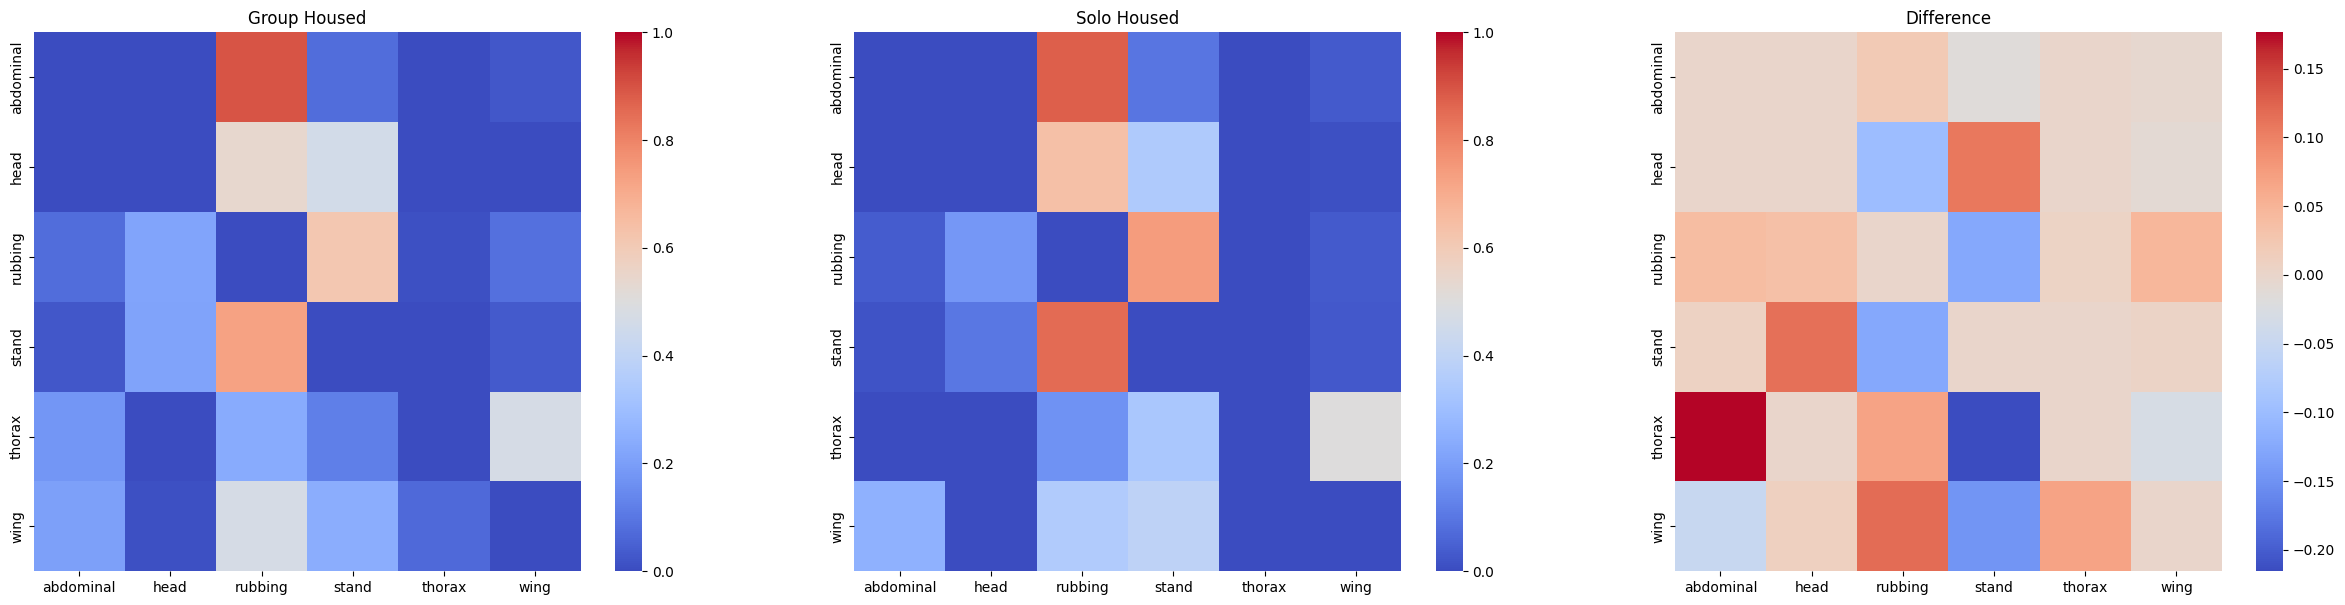

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(30, 7), sharex=True)

sns.heatmap(group_housed.mean_markovs_new(), ax = axes[0], vmin=0, vmax=1, cmap = "coolwarm")
axes[0].set_title('Group Housed')

sns.heatmap(solo_housed.mean_markovs_new(), ax = axes[1], vmin=0, vmax=1, cmap = "coolwarm")
axes[1].set_title('Solo Housed')

sns.heatmap(group_housed.mean_markovs_new() - solo_housed.mean_markovs_new(), ax = axes[2], cmap = "coolwarm")
axes[2].set_title('Difference')

### Embeddings

Create embeddings with TSNE and plot clustering (lack thereof)

In [ ]:
embedder = TSNE(
    n_components=3,
    init="random",
    max_iter=1000,
    random_state=1,
)

# embedder = PCA(
#     n_components=3
# )
X = [np.reshape(df.values, 36) for df in group_housed.probability_list + solo_housed.probability_list]
X_f = [np.reshape(df.values, 36) for df in group_housed.frequency_list + solo_housed.probability_list]

reduced_syntax = embedder.fit_transform(np.array(X))

<Axes: >

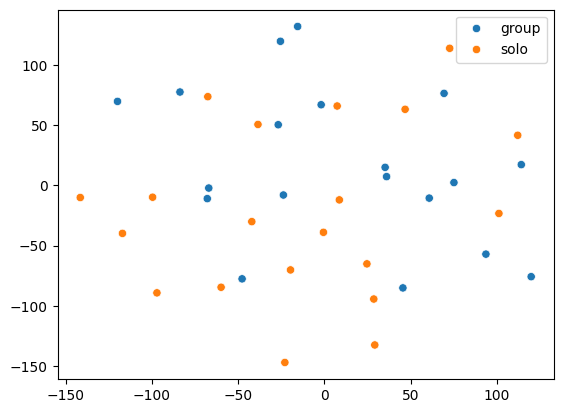

In [4]:
sns.scatterplot(x=reduced_syntax[:, 0], y=reduced_syntax[:, 1], hue=genotype_list)

In [ ]:
gh_mu_list, gh_mu = group_housed.get_entropy()
sh_mu_list, sh_mu = solo_housed.get_entropy()

/Users/anu/Documents/carleton/fly_syntax_nlp/.venv/lib/python3.11/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)
/Users/anu/Documents/carleton/fly_syntax_nlp/.venv/lib/python3.11/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)
/Users/anu/Documents/carleton/fly_syntax_nlp/.venv/lib/python3.11/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)
/Users/anu/Documents/carleton/fly_syntax_nlp/.venv/lib/python3.11/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)
/Users/anu/Documents/carleton/fly_syntax_nlp/.venv/lib/python3.11/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log2
  re

<Axes: ylabel='Count'>

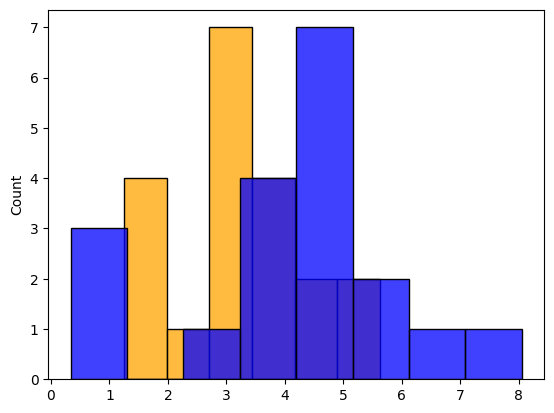

In [7]:
sns.histplot(sh_mu_list, color="orange")
sns.histplot(gh_mu_list, color="blue")